# METRICS VISUALIZATION

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
df = pd.read_csv('/mnt/jack-5/amismailov/inference_results/final_metrics.csv', index_col=0)
df.rename(columns={'R2_K1': 'K1', 'R2_K2': 'K2', 'R2_K3': 'K3', 'R2_K4': 'K4', 'R2_K5': 'K5', 'R2_K10': 'K10'}, inplace=True)
df

,K1,K2,K3,K4,K5,K10,n_sc,n_bulk,n_total
target,,,,,,,,,
hsa-let-7a-2-3p,0.050805,0.115669,0.172018,0.241204,0.275982,0.480928,36,724,760
hsa-let-7a-3p,0.360118,0.418064,0.478168,0.519095,0.538943,0.566822,186,50,236
hsa-let-7a-5p,0.624040,0.792798,0.922942,0.935838,0.943755,0.952733,154,235,389
hsa-let-7b-5p,0.836182,0.784030,0.761057,0.740283,0.728759,0.734769,298,50,348
hsa-let-7c-3p,0.008840,0.095973,0.114397,0.151361,0.162221,0.206518,33,50,83
...,...,...,...,...,...,...,...,...,...
hsa-mir-96-5p,0.185428,0.228006,0.452833,0.495680,0.517880,0.818616,108,100,208
hsa-mir-98-5p,0.606884,0.755220,0.817675,0.825570,0.842848,0.829487,175,547,722
hsa-mir-99a-5p,0.449056,0.675581,0.764297,0.844941,0.872843,0.910759,226,50,276


In [4]:
feat_cols = ['K1', 'K2', 'K3', 'K4', 'K5', 'K10']
df = df[feat_cols]
df

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7a-2-3p,0.050805,0.115669,0.172018,0.241204,0.275982,0.480928
hsa-let-7a-3p,0.360118,0.418064,0.478168,0.519095,0.538943,0.566822
hsa-let-7a-5p,0.624040,0.792798,0.922942,0.935838,0.943755,0.952733
hsa-let-7b-5p,0.836182,0.784030,0.761057,0.740283,0.728759,0.734769
hsa-let-7c-3p,0.008840,0.095973,0.114397,0.151361,0.162221,0.206518
...,...,...,...,...,...,...
hsa-mir-96-5p,0.185428,0.228006,0.452833,0.495680,0.517880,0.818616
hsa-mir-98-5p,0.606884,0.755220,0.817675,0.825570,0.842848,0.829487
hsa-mir-99a-5p,0.449056,0.675581,0.764297,0.844941,0.872843,0.910759


In [188]:
def select_optimal_k(df, rel_delta=0.05):
    Ks = [1, 2, 3, 4, 5, 10]

    dict_predict = {}

    for mir in df.index:
        
        scores = df.loc[mir].values
        best_score = scores.max()

        if best_score > 0.4:

            candidate_idx = np.where(
                scores >= best_score * (1 - rel_delta)
            )[0]

            chosen_idx = candidate_idx[0]  # минимальный K среди подходящих

            K = Ks[chosen_idx]

            dict_predict.setdefault(f'K{K}', [])
            dict_predict[f'K{K}'].append(mir)

    return dict_predict


In [189]:
dict_predict = select_optimal_k(df, rel_delta=0.075)

In [185]:
len(dict_predict['K10'])

76

/mnt/jack-1/tmp/ipykernel_2593407/313145524.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/mnt/jack-1/tmp/ipykernel_2593407/313145524.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="")


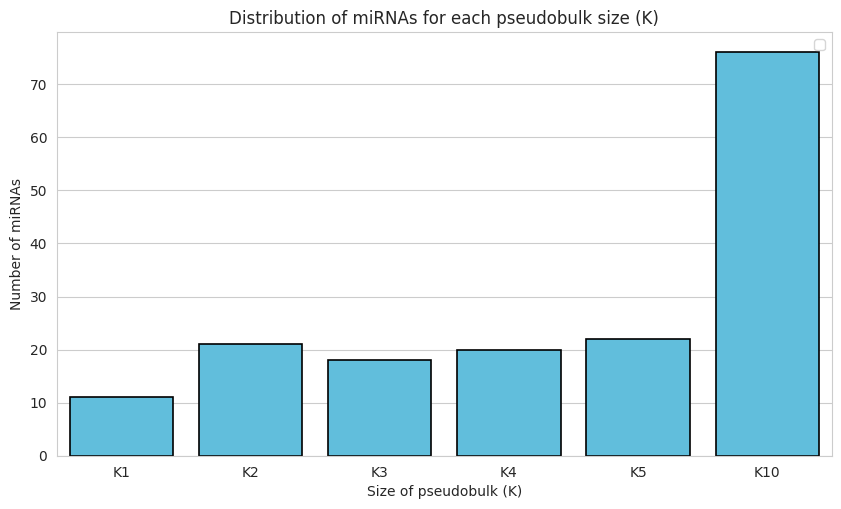

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path('/mnt/jack-5/amismailov/inference_results/plots')
def _save(fig: plt.Figure, name: str) -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT / f"{name}.pdf", format="pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(OUT / f"{name}.png", format="png", bbox_inches="tight", facecolor="white")
    plt.close(fig)


def _miRNA_distribution_by_k(dict_predict: dict) -> None:
    rows = []

    for k_val, mirnas in dict_predict.items():
        rows.append({
            "K_value": k_val,
            "count": len(mirnas)
        })

    plot_df = pd.DataFrame(rows)

    # порядок K
    k_order = sorted(plot_df["K_value"].unique(), key=lambda x: int(x.replace("K", "")))

    plot_df["K_value"] = pd.Categorical(
        plot_df["K_value"],
        categories=k_order,
        ordered=True
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))

    col = '#4cc9f0'
    sns.barplot(
        data=plot_df,
        x="K_value",
        y="count",
        palette={
            "K1": col,
            "K2": col,
            "K3": col,
            "K4": col,
            "K5": col,
            "K10": col
        },
        edgecolor="black",
        linewidth=1.2,
        ax=ax,
    )

    ax.set_xlabel("Size of pseudobulk (K)")
    ax.set_ylabel("Number of miRNAs")
    ax.set_title("Distribution of miRNAs for each pseudobulk size (K)")
    ax.legend(title="")

    _save(fig, "miRNA_distribution_by_k")

    return fig

_miRNA_distribution_by_k(dict_predict)

In [191]:
res = []
for k, v in dict_predict.items():
    res.extend(df.loc[v][k])
res = np.array(res)


print(f'Mean R2: {np.mean(res)}')
print(f'Median R2: {np.median(res)}')
print(f'Max R2: {np.max(res)}')
print(f'Min R2: {np.min(res)}')

Mean R2: 0.7819917077132734
Median R2: 0.8211907903344315
Max R2: 0.9687530582312788
Min R2: 0.4018973633727697


In [198]:
df.loc[dict_predict['K1']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7b-5p,0.836182,0.784030,0.761057,0.740283,0.728759,0.734769
hsa-mir-100-5p,0.932277,0.892880,0.880024,0.870757,0.862404,0.842481
hsa-mir-125b-5p,0.850052,0.834091,0.813639,0.819650,0.815808,0.850785
hsa-mir-142-3p,0.924208,0.969616,0.967014,0.965600,0.960224,0.950450
hsa-mir-17-5p,0.967506,0.964607,0.973919,0.977270,0.981349,0.989276
hsa-mir-20a-5p,0.950332,0.938512,0.950290,0.955156,0.962931,0.978175
hsa-mir-21-5p,0.946352,0.953753,0.968581,0.971381,0.977273,0.985509
hsa-mir-22-3p,0.413537,0.413858,0.402077,0.378160,0.296494,0.441781
hsa-mir-27b-3p,0.939259,0.968563,0.978502,0.983405,0.987049,0.993980


In [199]:
df.loc[dict_predict['K2']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7d-5p,0.674738,0.752040,0.810637,0.803902,0.797063,0.808359
hsa-let-7i-5p,0.777471,0.930618,0.940970,0.938228,0.936299,0.921176
hsa-mir-1301-3p,0.735229,0.863402,0.850014,0.834554,0.820838,0.813848
hsa-mir-130a-3p,0.664299,0.903754,0.929642,0.952602,0.955444,0.933406
hsa-mir-139-5p,0.440178,0.587500,0.602354,0.618718,0.613072,0.598753
hsa-mir-181a-5p,0.788300,0.864276,0.890481,0.878960,0.882176,0.856531
hsa-mir-18a-5p,0.704745,0.934278,0.957967,0.962219,0.969296,0.982859
hsa-mir-193a-5p,0.594462,0.776394,0.769434,0.757605,0.745485,0.754068
hsa-mir-19a-3p,0.881190,0.911453,0.935736,0.949251,0.952788,0.968626


In [200]:
df.loc[dict_predict['K3']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7a-5p,0.624040,0.792798,0.922942,0.935838,0.943755,0.952733
hsa-let-7g-5p,0.647623,0.688289,0.742654,0.763275,0.770068,0.784137
hsa-mir-106a-5p,0.638934,0.896508,0.930982,0.941890,0.954163,0.975858
hsa-mir-135b-5p,0.617995,0.654016,0.703984,0.694244,0.707887,0.669941
hsa-mir-148a-3p,0.583666,0.825571,0.910923,0.937316,0.949003,0.973263
hsa-mir-21-3p,0.452324,0.597870,0.713726,0.715085,0.770720,0.755242
hsa-mir-27a-3p,0.732293,0.892162,0.966112,0.978282,0.983144,0.993849
hsa-mir-34a-5p,0.504974,0.712873,0.768622,0.782524,0.789137,0.811135
hsa-mir-374a-5p,0.772113,0.858288,0.901954,0.917398,0.939430,0.967459


In [201]:
df.loc[dict_predict['K4']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-mir-103a-3p,0.730948,0.821560,0.861807,0.887538,0.907131,0.938135
hsa-mir-125a-5p,0.609172,0.758927,0.817059,0.852021,0.868498,0.919134
hsa-mir-1271-5p,0.403726,0.668137,0.819479,0.889811,0.912853,0.952658
hsa-mir-128-3p,0.462384,0.837961,0.880055,0.904915,0.924977,0.952044
hsa-mir-138-5p,0.623970,0.720821,0.762764,0.784927,0.782840,0.828978
hsa-mir-148b-3p,0.675366,0.822872,0.875962,0.898663,0.920246,0.959843
hsa-mir-224-3p,0.478616,0.535230,0.636786,0.683591,0.692030,0.709312
hsa-mir-224-5p,0.448557,0.490101,0.513417,0.563254,0.526568,0.549589
hsa-mir-31-5p,0.794079,0.808681,0.820087,0.835923,0.849400,0.892583


In [202]:
df.loc[dict_predict['K5']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7a-3p,0.360118,0.418064,0.478168,0.519095,0.538943,0.566822
hsa-let-7e-5p,0.340678,0.551373,0.684859,0.824019,0.848688,0.906894
hsa-let-7f-5p,0.569082,0.664445,0.771761,0.889762,0.900021,0.962193
hsa-mir-106b-5p,0.607042,0.715420,0.802830,0.820714,0.850927,0.898316
hsa-mir-149-5p,0.185331,0.394074,0.576691,0.675855,0.753785,0.789902
hsa-mir-181a-2-3p,0.194641,0.326980,0.471978,0.542245,0.580952,0.614346
hsa-mir-191-5p,0.653870,0.750734,0.807620,0.844225,0.877369,0.922018
hsa-mir-25-3p,0.280122,0.617609,0.707464,0.769846,0.798308,0.859019
hsa-mir-26a-5p,0.629376,0.775981,0.825592,0.864172,0.880799,0.935736


In [203]:
df.loc[dict_predict['K10']]

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7a-2-3p,0.050805,0.115669,0.172018,0.241204,0.275982,0.480928
hsa-let-7c-5p,0.498496,0.695360,0.769793,0.783147,0.799791,0.884402
hsa-mir-107,0.133190,0.233212,0.457392,0.606689,0.675045,0.817646
hsa-mir-1180-3p,0.149957,0.242286,0.344246,0.411365,0.456808,0.608629
hsa-mir-1185-1-3p,-0.027288,0.182061,0.237991,0.279528,0.374417,0.547922
...,...,...,...,...,...,...
hsa-mir-889-3p,0.274068,0.464109,0.571966,0.679585,0.742394,0.908021
hsa-mir-9-3p,0.564378,0.525463,0.571623,0.610382,0.678434,0.794198
hsa-mir-92a-1-5p,0.352483,0.335003,0.393824,0.424085,0.474789,0.702533


# bulk metrics

In [204]:
eligible_mirs = [mir for val in dict_predict.values() for mir in val]

In [205]:
df_bulk = pd.read_csv('/mnt/jack-5/amismailov/inference_results/bulk_test_metrics.csv', index_col=0)
df_bulk

,status,R2_bulk,n_bulk_test,n_sc,n_bulk,n_total,fallback
target,,,,,,,
hsa-let-7a-2-3p,ok,0.572541,5337,36,724,760,False
hsa-let-7a-3p,ok,0.693791,5337,186,50,236,False
hsa-let-7a-5p,ok,0.969904,5337,154,235,389,False
hsa-let-7b-5p,ok,0.434186,5337,298,50,348,False
hsa-let-7c-3p,ok,0.563162,5337,33,50,83,False
...,...,...,...,...,...,...,...
hsa-mir-96-5p,ok,0.570132,5337,108,100,208,False
hsa-mir-98-5p,ok,0.796111,5337,175,547,722,False
hsa-mir-99a-5p,ok,0.895675,5337,226,50,276,False


In [206]:
bulk_r2 = np.array(df_bulk.loc[eligible_mirs]['R2_bulk'])


print(f'Mean R2: {np.mean(bulk_r2)}')
print(f'Median R2: {np.median(bulk_r2)}')
print(f'Max R2: {np.max(bulk_r2)}')
print(f'Min R2: {np.min(bulk_r2)}')

Mean R2: 0.7549600624530952
Median R2: 0.7795776722819989
Max R2: 0.9754003371629376
Min R2: 0.1230431610240435


In [207]:
df_bulk = df_bulk.loc[eligible_mirs]
bulk_outliers = df_bulk[df_bulk['R2_bulk'] < 0.4].index.tolist()
bulk_outliers

['hsa-mir-29a-3p', 'hsa-mir-556-3p', 'hsa-mir-585-5p', 'hsa-mir-7-1-3p']

In [208]:
eligible_mirs = [mir for mir in eligible_mirs if mir not in bulk_outliers]
len(eligible_mirs)


164

## SAVE PREDICTION CONFIG

In [ ]:
dict_predict['eligible mirs'] = eligible_mirs
dict_predict.keys()

dict_keys(['K10', 'K5', 'K3', 'K1', 'K2', 'K4', 'eligible mirs'])

In [227]:
import json

with open('/mnt/jack-5/amismailov/inference_results/prediction_config_v3.json', 'w') as f:
    json.dump(dict_predict, f)

## VISUALIZATION

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

K_COHORTS = ("K1", "K2", "K3", "K4", "K5", "K10", 'BULK')
R2_THRESHOLD = 0.4
K_COLORS = {
    "K1": "#1f77b4",
    "K2": "#2ca02c",
    "K3": "#ff7f0e",
    "K4": "#d62728",
    "K5": "#9467bd",
    "K10": "#FF1493",
    "BULK": "black"
}

OUT = Path('/mnt/jack-5/amismailov/inference_results/plots')
def _save(fig: plt.Figure, name: str) -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT / f"{name}.pdf", format="pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(OUT / f"{name}.png", format="png", bbox_inches="tight", facecolor="white")
    plt.close(fig)



def _r2_lines_by_target(df: pd.DataFrame) -> None:
    order = df.sort_values("R2_K1")["target"].tolist()
    x = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(18, 7))

    for k in K_COHORTS:
        col = f"R2_{k}"
        y = df.set_index("target").reindex(order)[col].to_numpy()
        lw = 2.8 if k == "K1" else 1.6
        alpha = 1.0 if k in ("K1", "K10") else 0.75
        zorder = 4 if k == "K10" else (3 if k == "K1" else 2)
        ax.plot(x, y, label=k, color=K_COLORS[k], lw=lw, alpha=alpha, zorder=zorder)

    ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45, label=f"R²={R2_THRESHOLD}")
    ax.set_xlabel("Targets (sorted by K1 test R²)")
    ax.set_ylabel("Test R²")
    ax.set_title("Per-target R² across K1–K10 (CatBoost+TabM+ResNet stack)")
    tick_step = 10
    ticks = x[::tick_step]
    ax.set_xticks(ticks)
    #ax.set_xticklabels([order[i] for i in ticks], rotation=65, ha="right", fontsize=6)
    ax.legend(loc="upper left", ncol=4, fontsize=9)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    _save(fig, 'r2_lines_by_target')
    return fig



In [212]:
df_ = pd.read_csv('/mnt/jack-5/amismailov/inference_results/final_metrics.csv')
df_bulk_ = pd.read_csv('/mnt/jack-5/amismailov/inference_results/bulk_test_metrics.csv')

merged = df_.merge(df_bulk_[['target', 'R2_bulk']], on = 'target', how = 'left')
merged.rename(columns={'R2_bulk': 'R2_BULK'}, inplace=True)

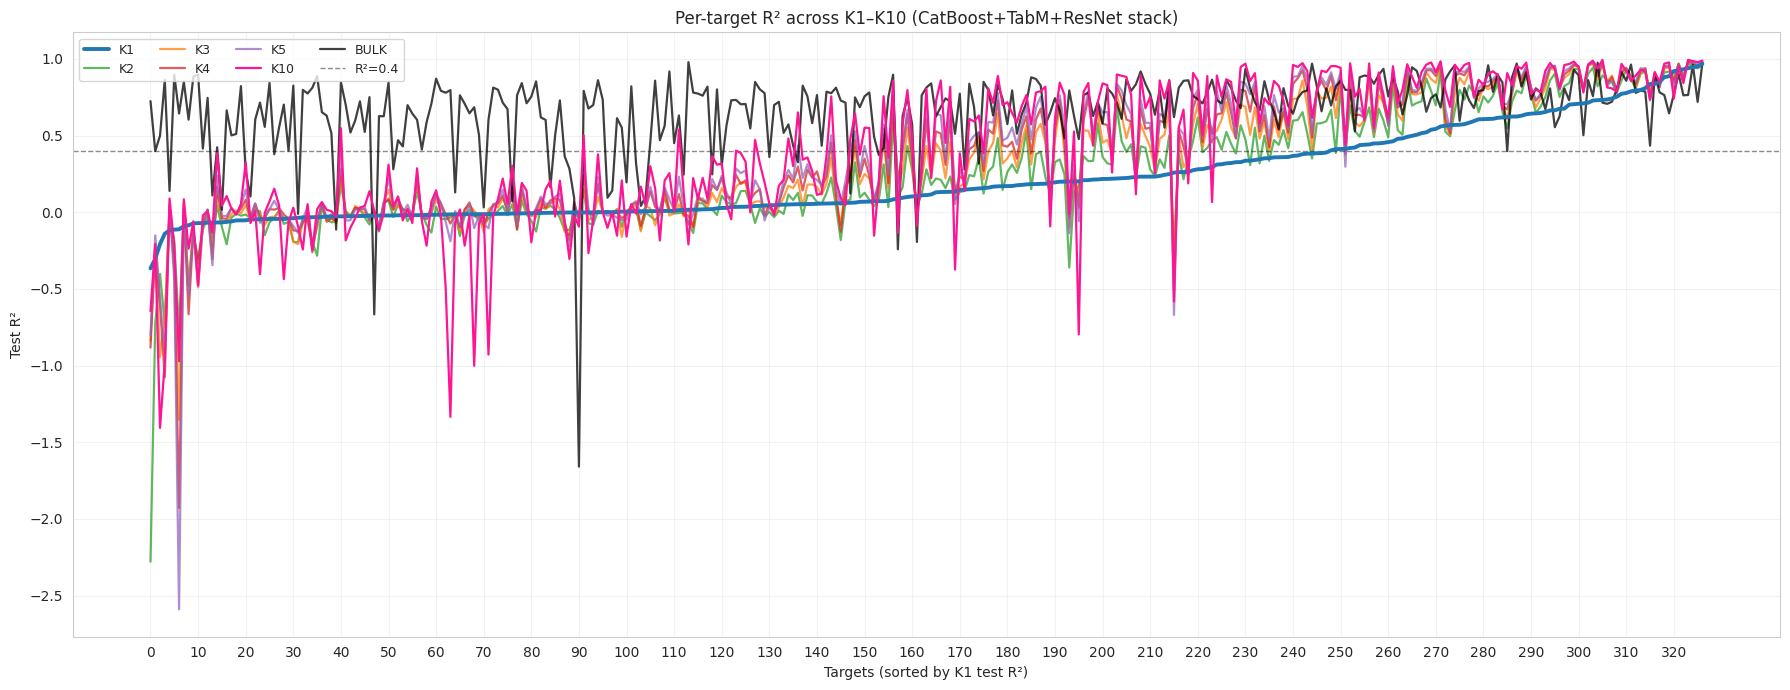

In [213]:
_r2_lines_by_target(merged)

In [214]:
def _r2_mean_median_by_k(df: pd.DataFrame) -> None:
    rows = []
    for k in K_COHORTS:
        col = f"R2_{k}"
        rows.append({"cohort": k, "stat": "mean", "r2": df[col].mean()})
        rows.append({"cohort": k, "stat": "median", "r2": df[col].median()})
    plot_df = pd.DataFrame(rows)
    plot_df["cohort"] = pd.Categorical(plot_df["cohort"], categories=list(K_COHORTS), ordered=True)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    sns.barplot(
        data=plot_df,
        x="cohort",
        y="r2",
        hue="stat",
        order=list(K_COHORTS),
        palette={"mean": "#5f00ff", "median": "#00ffd7"},
        edgecolor='black',
        ax=ax,
    )
    #ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    ax.set_xlabel("Cohort")
    ax.set_ylabel("Test R²")
    ax.set_title("Mean / median test R² across cohorts")
    ax.legend(title="")
    _save(fig, "r2_mean_median_by_k")
    return fig


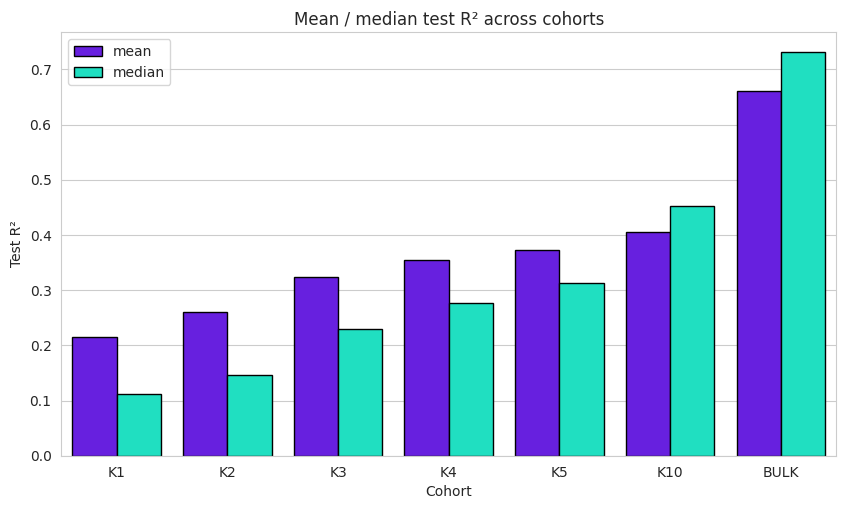

In [215]:
_r2_mean_median_by_k(merged)

In [216]:
ELIGIBLE_COLOR = "#FF1493"
OTHER_COLOR = "#708090"
K_COHORTS = ("K1", "K2", "K3", "K4", "K5", "K10", 'BULK')
R2_COLS = [f"R2_{k}" for k in K_COHORTS]

def _eligible_vs_rest(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    sns.kdeplot(data=df, x="R2_K1", hue="eligible", fill=True, common_norm=False, ax=axes[0], palette={
        True: ELIGIBLE_COLOR,
        False: OTHER_COLOR,
    })
    axes[0].axvline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    axes[0].set_xlabel("K1 test R²")
    axes[0].set_title("K1 R² density: eligible vs rest")
    axes[0].legend(title="", labels=[f"eligible (n={df['eligible'].sum()})", f"other (n={(~df['eligible']).sum()})"])

    long = df[df["eligible"]].melt(
        id_vars="target",
        value_vars=R2_COLS,
        var_name="cohort",
        value_name="r2",
    )
    long["cohort"] = long["cohort"].str.replace("R2_", "", regex=False)
    long["cohort"] = pd.Categorical(long["cohort"], categories=list(K_COHORTS), ordered=True)
    sns.boxplot(
        data=long,
        x="cohort",
        y="r2",
        order=list(K_COHORTS),
        palette=[K_COLORS[k] for k in K_COHORTS],
        ax=axes[1],
    )
    axes[1].axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    axes[1].set_xlabel("Assigned cohort")
    axes[1].set_ylabel("Test R² at assigned K")
    axes[1].set_title("Eligible targets: R² at assigned cohort")
    fig.tight_layout()
    _save(fig, "eligible_vs_rest_k1")
    return fig

In [217]:
merged['eligible'] = merged['target'].isin(eligible_mirs)

/mnt/jack-1/tmp/ipykernel_2593407/645403436.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


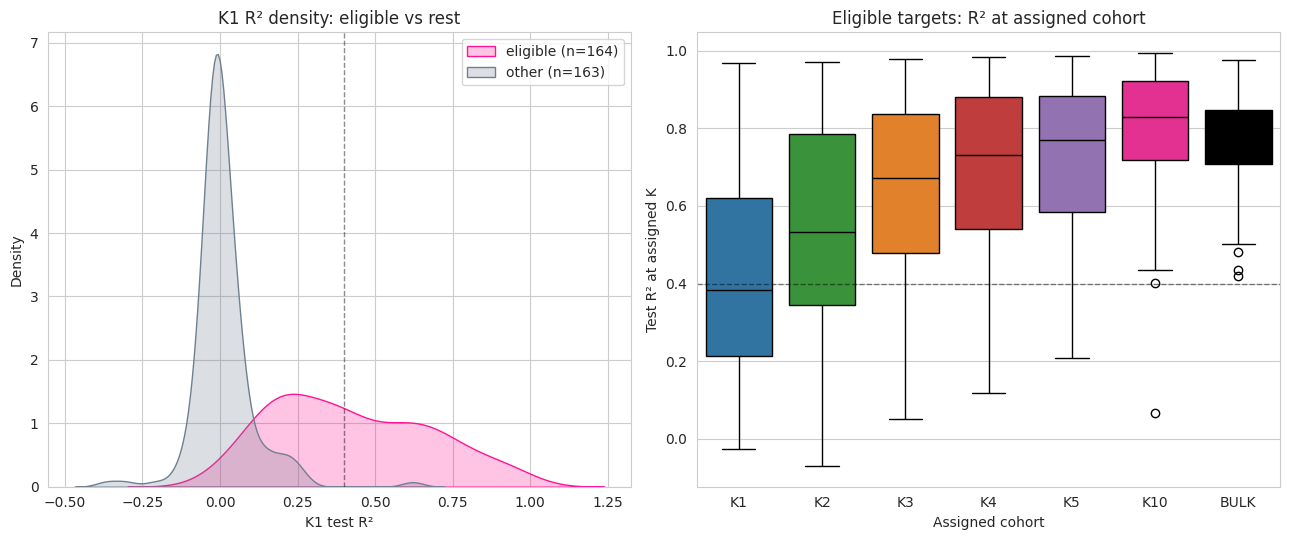

In [218]:
_eligible_vs_rest(merged)

In [219]:
from scipy import stats
import matplotlib.colors as mcolors
def _scatter_features_vs_k1(df: pd.DataFrame, x_col: str, x_label: str, fname: str, color: str = '#00ffd7') -> None:
    fig, ax = plt.subplots(figsize=(9, 6.5))
    
    face = mcolors.to_rgba(color, alpha=0.5)

    ax.scatter(
            df[x_col],
            df["R2_K1"],
            c=face,
            s=42,
            edgecolors="black",
            linewidths=0.4
        )

    x = df[x_col].to_numpy(dtype=float)
    y = df["R2_K1"].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 3:
        slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
        xs = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="#222222", lw=2, alpha=0.85, zorder=1)
        ax.text(
            0.03,
            0.97,
            f"Pearson r = {r:.3f}\np = {p:.2e}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor="#ccc"),
        )

    #ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Test R² (K1 single-cell)")
    ax.set_title(f"K1 performance vs {x_label}")
    #ax.legend(loc="lower right", framealpha=0.95)
    _save(fig, fname)
    return fig

/mnt/jack-1/tmp/ipykernel_2593407/2408930496.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


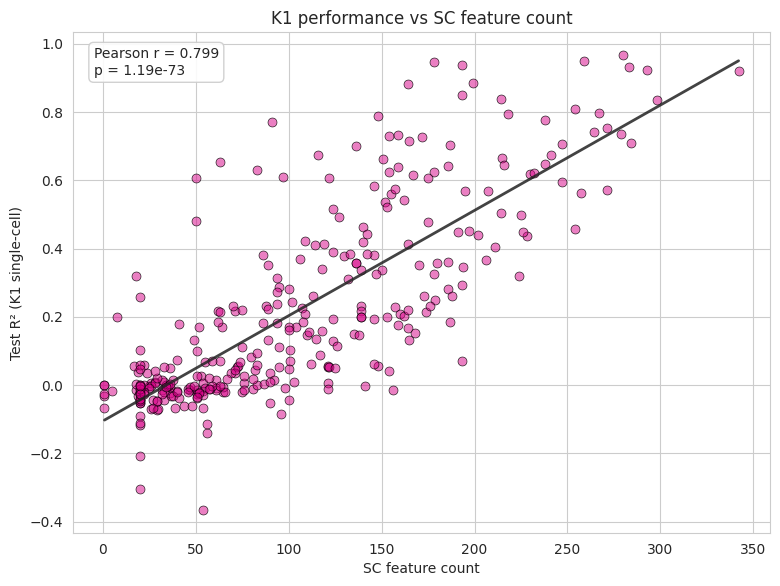

In [220]:
_scatter_features_vs_k1(merged, "n_sc", "SC feature count", 'n_sc_vs_k1', color='#d70087')

/mnt/jack-1/tmp/ipykernel_2593407/2408930496.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


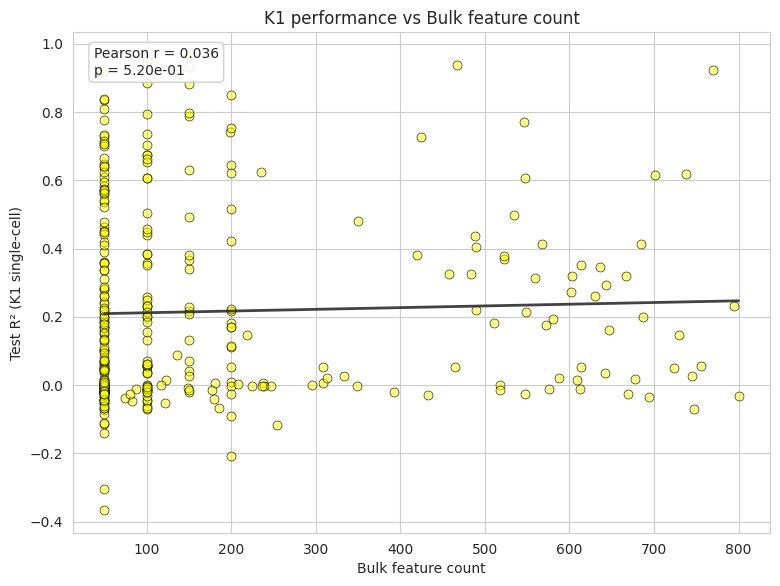

In [221]:
_scatter_features_vs_k1(merged, "n_bulk", "Bulk feature count", 'n_bulk_vs_k1', color='#ffff00')